In [1]:
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from boats.lib.common import *
from boats.lib.boat import Boat

In [2]:
boatname = 'Petsamo'

sails = ['Nr.1', 'Nr.2', 'Nr.3', 'Stormjib', 'Mainsail', 'Genaker', 'Mizzen', 'Mizzen staysail']
points_of_sail={
    'close haul': list(range(0,37)),
    'close reach': list(range(36,73)),
    'beam': list(range(72,109)),
    'broad reach': list(range(108,145)),
    'run': list(range(144,181))
}
yesmark = 'x'
nomark = '-'

In [7]:
df=Boat(boatname).get_logged_data()
df.dropna(inplace=True)
df['heel']=df['heel'].apply(lambda x: int(abs(x)))
df['twa']=df['twa'].apply(lambda x: abs(x))
df=df[df['spd']!=0]
df['spd / tws']=round(df['spd']/df['tws'],2)
df.reset_index(inplace=True, drop=True)
df.head()

,tws,spd,twd,twa,heel,sails,lat,lon,awa,spd / tws
0,28.8,5.9,26,45,36,"[Mainsail, Stormjib]",33.81015,141.29803,-38.0,0.2
1,28.8,5.9,26,45,36,"[Mainsail, Stormjib]",33.81015,141.29803,-38.0,0.2


In [8]:
len(df)

2

#### Expand sail data:

In [5]:
for i in range(len(df.index)):
    for sail in sails:
        if sail in df.iloc[i]['sails']:
            mark = yesmark
        else:
            mark = nomark
        df.at[i, sail] = mark
        
df.drop(['sails'], axis=1, inplace=True)
df.head()    

,tws,spd,twd,twa,heel,lat,lon,awa,spd / tws,Nr.1,Nr.2,Nr.3,Stormjib,Mainsail,Genaker,Mizzen,Mizzen staysail
0,28.8,5.9,26,45,36,33.81015,141.29803,-38.0,0.2,-,-,-,x,x,-,-,-


In [10]:
df['pos']=[name for i in range(len(df.index)) for name in points_of_sail if df.iloc[i]['twa'] in points_of_sail[name]]

[Text(0.5, 1.0, 'Speed by point of sale')]

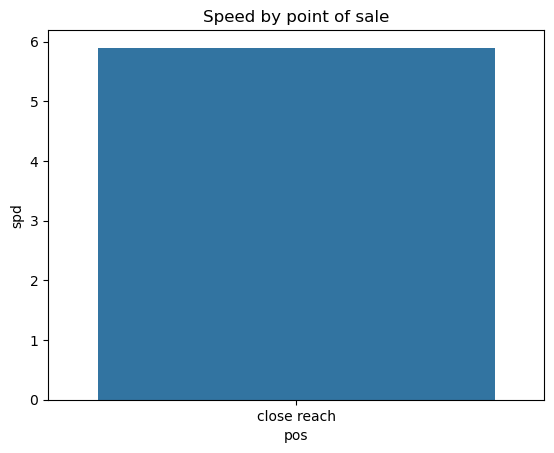

In [11]:
df_plot=df[['pos', 'spd']].groupby('pos').mean().sort_values('pos')
sns.barplot(data=df_plot, x=df_plot.index, y='spd').set(title='Speed by point of sale')

[Text(0.5, 1.0, 'Points of sail frequency')]

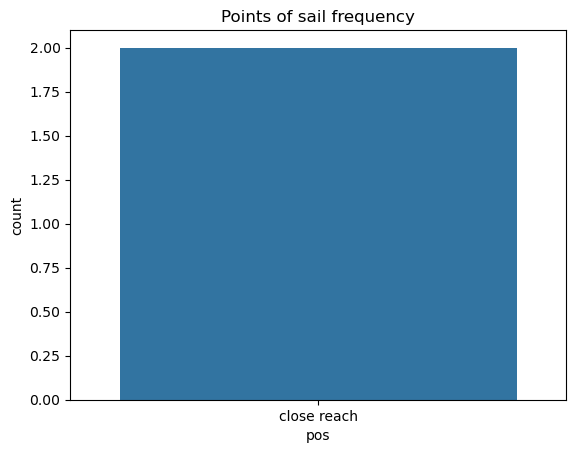

In [12]:
sns.countplot(data=df.sort_values('pos'), x='pos').set(title='Points of sail frequency')

[Text(0.5, 1.0, 'Speed by heel')]

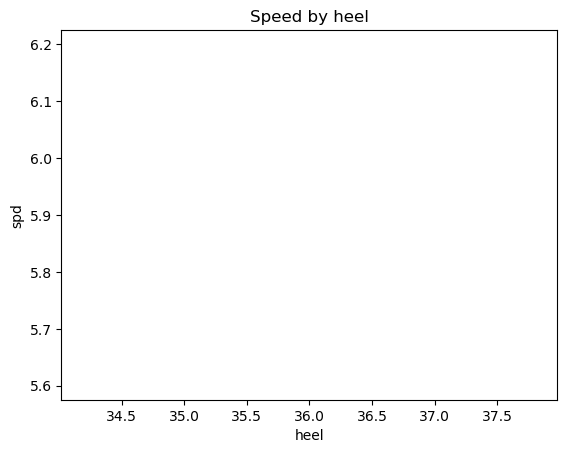

In [13]:
df_plot=df[['heel', 'spd']].groupby('heel').mean()
sns.lineplot(data=df_plot, x=df_plot.index, y='spd').set(title='Speed by heel')

[Text(0.5, 1.0, 'spd to tws')]

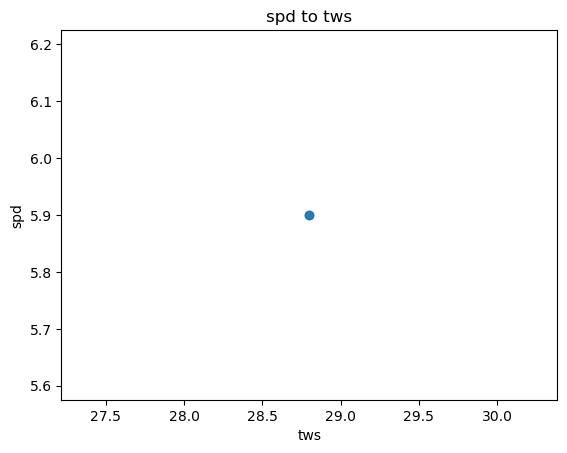

In [14]:
sns.regplot(data=df, x='tws', y='spd').set(title='spd to tws')

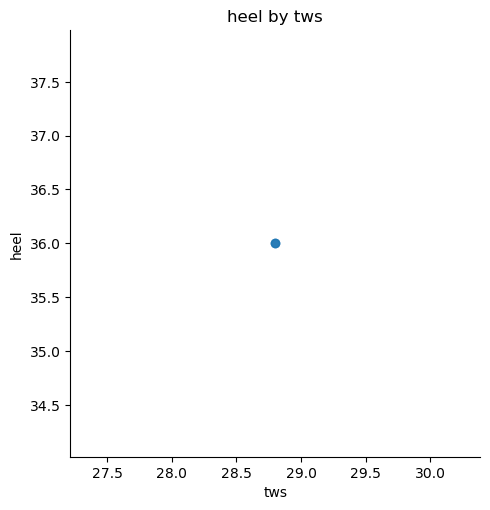

In [15]:
sns.lmplot(data=df, x='tws', y='heel').set(title='heel by tws')

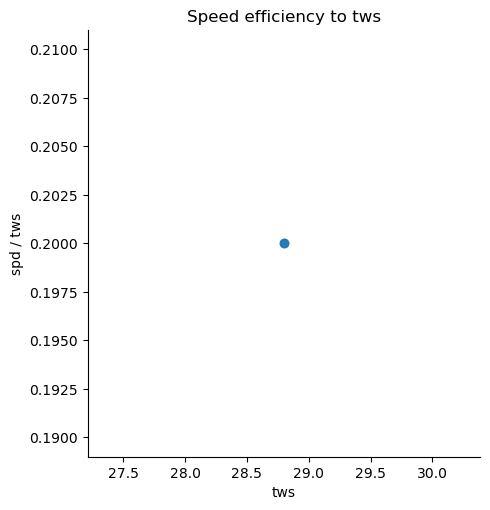

In [16]:
sns.lmplot(data=df, x='tws', y='spd / tws').set(title='Speed efficiency to tws')

In [17]:
df_pos=df.sort_values('twa')[['pos'] + sails].reset_index(drop=True)
df_pos

KeyError: "['Nr.1', 'Nr.2', 'Nr.3', 'Stormjib', 'Mainsail', 'Genaker', 'Mizzen', 'Mizzen staysail'] not in index"

In [ ]:
df_pos=df_pos.replace(yesmark, 1)
df_pos=df_pos.replace(nomark, 0)
df_pos

In [ ]:
df_plot=df_pos.groupby('pos').sum()
df_plot

In [ ]:
sns.heatmap(df_plot).set(title='Sail types usage by point of sail')

In [ ]:
for sail in sails:
    sns.lmplot(data=df, x='tws', y='spd', hue=sail).set(title='spd to tws by sail')